In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/OneDrive_xwc@zju.edu.cn/optimal-control/my-notes/code/with-notes/lec5`


In [2]:
using LinearAlgebra
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

## Equality Constraints With Regularization

In [3]:
Q = Diagonal([0.5; 1])
function f(x)
    return 0.5 * (x - [1; 0])' * Q * (x - [1; 0])
end
gradient_f = x -> ForwardDiff.gradient(x -> f(x), x);
hessian_f = x -> ForwardDiff.hessian(x -> f(x), x);

In [4]:
function c(x)
    return x[1]^2 + 2 * x[1] - x[2]
end
gradient_c = x -> ForwardDiff.gradient(x -> c(x), x);  # [2*x[1]+2 -1]

In [5]:
let
    x0 = [0, 0]
    @show f(x0)
    @show gradient_f(x0)
    @show hessian_f(x0)
    @show gradient_c(x0)
end;

f(x0) = 0.25
gradient_f(x0) = [-0.5, 0.0]
hessian_f(x0) = [0.5 0.0; 0.0 1.0]
gradient_c(x0) = [2, -1]


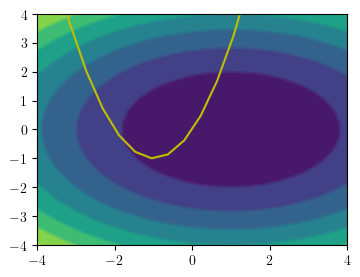

(-4.0, 4.0)

In [6]:
function plot_landscape()
    n_sample = 20
    x_sample = kron(ones(n_sample), LinRange(-4, 4, n_sample)')
    y_sample = kron(ones(n_sample)', LinRange(-4, 4, n_sample))
    z = [f([x, y]) for (x, y) in zip(x_sample, y_sample)]
    figure(figsize = (4, 3))
    contourf(x_sample, y_sample, z)
    contour(x_sample, y_sample, z)
    xc = LinRange(-4, 4, n_sample)
    plot(xc, [c([x 0]) for x in xc], "y")
    xlim([-4, 4])
    ylim([-4, 4])
end
plot_landscape()

### Full Newton's Step

In [7]:
function newton_step(x0, lambda0)
    H = hessian_f(x0) + ForwardDiff.jacobian(x -> gradient_c(x)' * lambda0, x0)
    C = gradient_c(x0)
    delta_z = [H C; C' 0] \ [-gradient_f(x0) - C * lambda0; -c(x0)]
    delta_x = delta_z[1:2]
    delta_lambda = delta_z[3]
    return x0 + delta_x, lambda0 + delta_lambda
end

newton_step (generic function with 1 method)

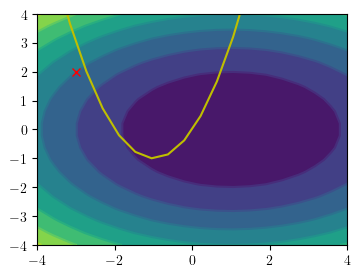

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f83c6a26610>

In [8]:
x_guess = [-3; 2]
lambda_guess = [0.0]
plot_landscape()
plot(x_guess[1], x_guess[2], "rx")

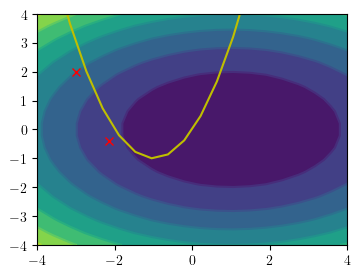

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f83c62cfbd0>

In [9]:
x_new, lambda_new = newton_step(x_guess[:, end], lambda_guess[end])
x_guess = [x_guess x_new]
lambda_guess = [lambda_guess lambda_new]
plot_landscape()
plot(x_guess[1, :], x_guess[2, :], "rx")  # 第一次超调是因为牛顿是一阶近似，沿切线走了一段距离

### Lagrangian Dual

In [10]:
function regularized_newton_step(x0, lambda0)
    H = hessian_f(x0) + ForwardDiff.jacobian(x -> gradient_c(x)' * lambda0, x0)
    C = gradient_c(x0)
    K = [H C; C' 0]
    e = eigvals(K)
    beta = 1.0
    while !(sum(e .> 0) == length(x0) && sum(e .< 0) == length(lambda0))
        K = K + Diagonal([beta * ones(length(x0)); -beta * ones(length(lambda0))])
        e = eigvals(K)
    end
    delta_z = K \ [-gradient_f(x0) - C * lambda0; -c(x0)]
    delta_x = delta_z[1:2]
    delta_lambda = delta_z[3]
    return x0 + delta_x, lambda0 + delta_lambda
end

regularized_newton_step (generic function with 1 method)

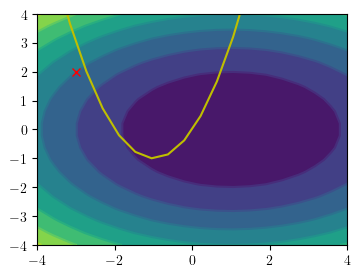

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f83c6314d50>

In [11]:
x_guess = [-3; 2]
lambda_guess = [0.0]
plot_landscape()
plot(x_guess[1], x_guess[2], "rx")

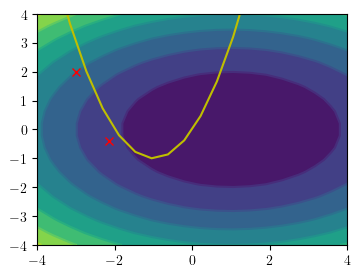

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f83c6020fd0>

In [12]:
x_new, lambda_new = regularized_newton_step(x_guess[:, end], lambda_guess[end])
x_guess = [x_guess x_new]
lambda_guess = [lambda_guess lambda_new]
plot_landscape()
plot(x_guess[1, :], x_guess[2, :], "rx")